# BlazePose와 LSTM을 이용하여 낙상 감지 판별

전체 파이프라인은 다음과 같습니다.


[.mp4 동영상] 
    ↓
[프레임 추출 + BlazePose]
    ↓
[프레임마다 33 x 4 = 132차원 관절 벡터] 
    ↓
[약 10초간 300개 벡터 → (300, 132) 배열]
    ↓
[LSTM에 입력 → 시계열 특징 학습]
    ↓
[Classifier → daily / falldown 분류]


## 1. BlazePose를 활용하여 관절 정보 추출

In [21]:
import cv2
import mediapipe as mp
import os
import glob

# 🔧 입력 및 출력 디렉토리 설정
video_base_dir = '/Users/ijiho/Documents/person_detect/DataSet/train'
output_root = '/Users/ijiho/Documents/person_detect/output_frames'
os.makedirs(output_root, exist_ok=True)

# 🔧 MediaPipe 초기화
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False)

# 🔁 모든 클래스(daily, falldown) 폴더 반복
for label_name in os.listdir(video_base_dir):
    label_path = os.path.join(video_base_dir, label_name)
    if not os.path.isdir(label_path):
        continue

    video_files = glob.glob(os.path.join(label_path, '*.mp4'))

    for video_path in video_files:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print("❌ 동영상 열기 실패:", video_path)
            continue

        video_name = os.path.splitext(os.path.basename(video_path))[0]
        output_dir = os.path.join(output_root, label_name, video_name)
        os.makedirs(output_dir, exist_ok=True)

        print(f"📹 처리 중: {label_name}/{video_name}")
        frame_count = 0

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = pose.process(rgb_frame)

            if results.pose_landmarks:
                mp_drawing.draw_landmarks(
                    frame,
                    results.pose_landmarks,
                    mp_pose.POSE_CONNECTIONS,
                    landmark_drawing_spec=mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=2),
                    connection_drawing_spec=mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=2)
                )

            save_path = os.path.join(output_dir, f"frame_{frame_count:03d}.jpg")
            cv2.imwrite(save_path, frame)
            frame_count += 1

        cap.release()
        print(f"✅ 완료: {label_name}/{video_name} → {frame_count}프레임 저장됨")

pose.close()


✅ 완료: daily/WD_in_W13W22_0003_20201023_14_10초 → 599프레임 저장됨
📹 처리 중: daily/WD_In_W12W21_0003_20201201_10_10초
✅ 완료: daily/WD_In_W12W21_0003_20201201_10_10초 → 599프레임 저장됨
📹 처리 중: daily/WD_In_W13W21_0003_20210101_12_10초
✅ 완료: daily/WD_In_W13W21_0003_20210101_12_10초 → 658프레임 저장됨
📹 처리 중: falldown/FD_In_H11H22H32_0004_20201016_13_10초_뒤없음_절반
✅ 완료: falldown/FD_In_H11H22H32_0004_20201016_13_10초_뒤없음_절반 → 301프레임 저장됨
📹 처리 중: falldown/FD_In_H11H22H33_0003_20201231_15_10초
✅ 완료: falldown/FD_In_H11H22H33_0003_20201231_15_10초 → 301프레임 저장됨
📹 처리 중: falldown/FD_In_H12H22H33_0003_20201015_10_10초
✅ 완료: falldown/FD_In_H12H22H33_0003_20201015_10_10초 → 311프레임 저장됨
📹 처리 중: falldown/FD_In_H12H22H33_0002_20201014_20_10초
✅ 완료: falldown/FD_In_H12H22H33_0002_20201014_20_10초 → 298프레임 저장됨
📹 처리 중: falldown/FD_In_H11H22H33_0004_20201231_19_10초
✅ 완료: falldown/FD_In_H11H22H33_0004_20201231_19_10초 → 313프레임 저장됨
📹 처리 중: falldown/FD_In_H11H22H32_0003_20201016_13_10초_뒤없음
✅ 완료: falldown/FD_In_H11H22H32_0003_20201016_13_10초_뒤없음 → 30

## 2. 프레임별 (x, y, z, visibility) 정보를 추출

이 코드는.mp4 영상을 BlazePose로 처리해 각 프레임에서 (x, y, z, visibility) 정보를 추출하고, 이를 (300, 132) 형식의 LSTM 입력 배열로 저장하는 코드이며, 저장된 파일의 형식은 NumPy의 배열 형태이다.

In [22]:
import cv2
import mediapipe as mp
import numpy as np
import os
import glob
from collections import Counter

# MediaPipe Pose 초기화
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False)

# 최대 프레임 수 설정 (예: 10초 @30fps)
MAX_FRAMES = 300
KEYPOINT_DIM = 132  # 33개 관절 × (x, y, z, visibility)

# 경로 설정
base_dir = '/Users/ijiho/Documents/person_detect/DataSet/train'
output_dir = '/Users/ijiho/Documents/person_detect/npy_data'
os.makedirs(output_dir, exist_ok=True)

X_data = []
y_data = []

label_dict = {'daily': 0, 'falldown': 1}

for label_name, label_num in label_dict.items():
    class_dir = os.path.join(base_dir, label_name)
    video_files = glob.glob(os.path.join(class_dir, '*.mp4'))

    print(f"\n📂 처리 중 클래스: {label_name} ({label_num}) - 총 {len(video_files)}개 파일")

    for video_path in video_files:
        cap = cv2.VideoCapture(video_path)
        keypoints_seq = []

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = pose.process(rgb_frame)

            if results.pose_landmarks:
                frame_keypoints = []
                for lm in results.pose_landmarks.landmark:
                    frame_keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
                keypoints_seq.append(frame_keypoints)

        cap.release()

        if len(keypoints_seq) == 0:
            print(f"⚠️ 관절 감지 실패: {os.path.basename(video_path)}")
            continue

        keypoints_seq = np.array(keypoints_seq)

        if keypoints_seq.shape[0] >= MAX_FRAMES:
            keypoints_seq = keypoints_seq[:MAX_FRAMES]
        else:
            padding = np.zeros((MAX_FRAMES - keypoints_seq.shape[0], KEYPOINT_DIM))
            keypoints_seq = np.vstack((keypoints_seq, padding))

        X_data.append(keypoints_seq)
        y_data.append(label_num)

        print(f"✅ 저장됨: {os.path.basename(video_path)} → shape {keypoints_seq.shape}")

pose.close()

# numpy array로 변환
X_data = np.array(X_data)  # shape: (N, 300, 132)
y_data = np.array(y_data)  # shape: (N,)

# ✅ 클래스별 저장 개수 출력
label_counts = Counter(y_data)
print("\n📊 클래스별 저장된 샘플 수:")
for label, count in label_counts.items():
    label_name = [k for k, v in label_dict.items() if v == label][0]
    print(f"  • {label_name} ({label}): {count}개")

print(f"\n📁 총 저장된 샘플 수: {len(X_data)}개")
print(f"📐 배열 크기: {X_data.shape}")

# ✅ 최종 저장
np.save(os.path.join(output_dir, 'X.npy'), X_data)
np.save(os.path.join(output_dir, 'y.npy'), y_data)
print("\n💾 X.npy와 y.npy 저장 완료")



📂 처리 중 클래스: daily (0) - 총 3개 파일
✅ 저장됨: WD_in_W13W22_0003_20201023_14_10초.mp4 → shape (300, 132)
✅ 저장됨: WD_In_W12W21_0003_20201201_10_10초.mp4 → shape (300, 132)
✅ 저장됨: WD_In_W13W21_0003_20210101_12_10초.mp4 → shape (300, 132)

📂 처리 중 클래스: falldown (1) - 총 7개 파일
✅ 저장됨: FD_In_H11H22H32_0004_20201016_13_10초_뒤없음_절반.mp4 → shape (300, 132)
✅ 저장됨: FD_In_H11H22H33_0003_20201231_15_10초.mp4 → shape (300, 132)
✅ 저장됨: FD_In_H12H22H33_0003_20201015_10_10초.mp4 → shape (300, 132)
✅ 저장됨: FD_In_H12H22H33_0002_20201014_20_10초.mp4 → shape (300, 132)
✅ 저장됨: FD_In_H11H22H33_0004_20201231_19_10초.mp4 → shape (300, 132)
✅ 저장됨: FD_In_H11H22H32_0003_20201016_13_10초_뒤없음.mp4 → shape (300, 132)
✅ 저장됨: FD_Out_H11H22H31_0002_20210114_09_10초_컷편집.mp4 → shape (300, 132)

📊 클래스별 저장된 샘플 수:
  • daily (0): 3개
  • falldown (1): 7개

📁 총 저장된 샘플 수: 10개
📐 배열 크기: (10, 300, 132)

💾 X.npy와 y.npy 저장 완료


📘 Epoch [1/20] - Loss: 0.6972
📘 Epoch [2/20] - Loss: 0.6817
📘 Epoch [3/20] - Loss: 0.6661
📘 Epoch [4/20] - Loss: 0.6494
📘 Epoch [5/20] - Loss: 0.6298
📘 Epoch [6/20] - Loss: 0.6058
📘 Epoch [7/20] - Loss: 0.5745
📘 Epoch [8/20] - Loss: 0.5326
📘 Epoch [9/20] - Loss: 0.4815
📘 Epoch [10/20] - Loss: 0.4238
📘 Epoch [11/20] - Loss: 0.3679
📘 Epoch [12/20] - Loss: 0.3193
📘 Epoch [13/20] - Loss: 0.2780
📘 Epoch [14/20] - Loss: 0.2422
📘 Epoch [15/20] - Loss: 0.7884
📘 Epoch [16/20] - Loss: 0.5364
📘 Epoch [17/20] - Loss: 0.5000
📘 Epoch [18/20] - Loss: 0.3999
📘 Epoch [19/20] - Loss: 0.1582
📘 Epoch [20/20] - Loss: 0.1522


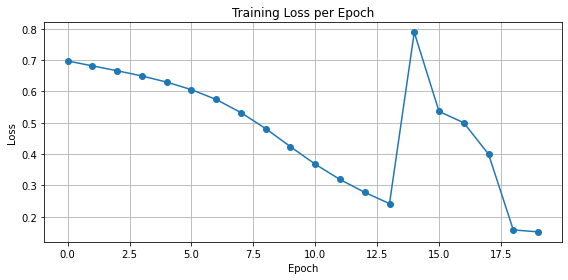


📄 Train Classification Report:
              precision    recall  f1-score   support

       daily       1.00      1.00      1.00         2
    falldown       1.00      1.00      1.00         6

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



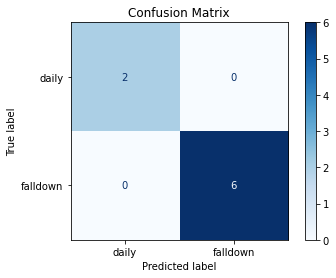


📄 Test Classification Report:
              precision    recall  f1-score   support

       daily       1.00      1.00      1.00         1
    falldown       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



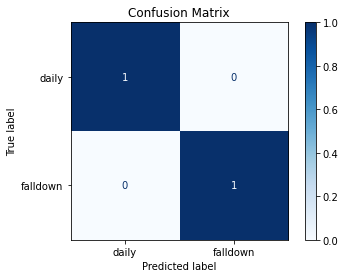

In [26]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from collections import Counter

# ✅ LSTM 모델 정의
class FallDetectionLSTM(nn.Module):
    def __init__(self, input_size=132, hidden_size=128, num_layers=1, num_classes=2):
        super(FallDetectionLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        out = self.fc(hn[-1])
        return out

# ✅ Confusion Matrix 함수
def plot_confusion_matrix(y_true, y_pred, class_names=["daily", "falldown"]):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title("Confusion Matrix")
    plt.show()

# ✅ 평가 함수
def evaluate_model(model, data_loader, device, set_name="Test"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    print(f"\n📄 {set_name} Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=["daily", "falldown"]))

    plot_confusion_matrix(all_labels, all_preds, class_names=["daily", "falldown"])

# ✅ 데이터 불러오기
X = np.load('/Users/ijiho/Documents/person_detect/npy_data/X.npy')  # (N, 300, 132)
y = np.load('/Users/ijiho/Documents/person_detect/npy_data/Y.npy')  # (N,)

# 텐서 변환
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y
)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# ✅ 학습 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FallDetectionLSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ✅ 학습 루프
num_epochs = 20
train_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"📘 Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")

# ✅ 학습 손실 시각화
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ Train/ Test 평가 및 시각화
evaluate_model(model, train_loader, device, set_name="Train")
evaluate_model(model, test_loader, device, set_name="Test")
